# Lens 2: Risk Identification
Scores each road segment on infrastructure and exposure risk derived from street-level imagery (YOLO object detection + VLM scene understanding). Higher score = greater risk from road environment, not speed.

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

## Load Data

The cleaned road-segment geometries (same base data used in Lens 1) are merged with the raw YOLO/VLM image-derived variables on `OBJECTID`. Rows without image coverage (no YOLO/VLM run) are dropped.

In [2]:
thai_gdf  = gpd.read_file('data/thai_clean_gdf.geojson')
india_gdf = gpd.read_file('data/india_clean_gdf.geojson')

thai_vars  = pd.read_csv('Risk_Score/variables_thailand.csv')
india_vars = pd.read_csv('Risk_Score/variables_maharashtra.csv')

image_cols_thai  = [c for c in thai_vars.columns  if c.startswith('yolo_') or c.startswith('vlm_')]
image_cols_india = [c for c in india_vars.columns if c.startswith('yolo_') or c.startswith('vlm_')]

thai_gdf  = thai_gdf.merge(thai_vars[['OBJECTID'] + image_cols_thai],   on='OBJECTID', how='inner')
india_gdf = india_gdf.merge(india_vars[['OBJECTID'] + image_cols_india], on='OBJECTID', how='inner')

thai_gdf  = thai_gdf.dropna(subset=image_cols_thai)
india_gdf = india_gdf.dropna(subset=image_cols_india)

print(f"Thailand: {thai_gdf.shape} | India: {india_gdf.shape}")

Thailand: (11062, 55) | India: (3421, 48)


## Feature Selection & Weights

`image_risk_score` is a weighted composite of normalised YOLO/VLM features. Weights were derived by fitting a logistic regression of these features against accident history in Thailand (see `Risk_Score/risk_score_cal_thailand.ipynb`), then adjusted with domain judgement — e.g. motorcycle presence is weighted up beyond its regression coefficient because it is a well-established risk factor in the literature that the sparse accident data underweighted.

Maharashtra's accident dataset did not have adequate geographic coverage to fit its own regression (accidents didn't represent most of the road network — see the map check in `risk_score_cal_maharashtra.ipynb`), so the same weighting logic is reused there, adapted to the subset of VLM fields that dataset has available (it lacks `vlm_pedestrian_crossing_visible`, `vlm_bike_lane_present`, and `vlm_footpath_obstruction`).

For both countries:
- **Positive-risk features** (higher raw value = higher risk) are used as-is after normalisation.
- **Negative-risk features** (higher raw value = lower risk — more lanes, better lane markings, better road condition, visible intersections) are inverted after normalisation (`1 - x`) so every weighted term points the same direction.

In [3]:
# Thailand: features + weights (from risk_score_cal_thailand.ipynb)
risk_features_thai = {
    # positives
    "yolo_total_vehicles":              0.19,  # coef = +0.328
    "vlm_population_density_score":     0.19,  # coef = +0.196
    "vlm_pedestrian_crossing_visible":  0.06,  # coef = +0.059
    "vlm_bike_lane_present":            0.05,  # coef = +0.052
    "yolo_total_pedestrians":           0.08,  # coef = +0.048
    "vlm_footpath_score":               0.05,  # coef = +0.025
    "vlm_footpath_obstruction":         0.03,  # coef = +0.012
    "yolo_total_bicycles":              0.03,  # coef = +0.013

    # negatives (inverted after normalisation)
    "vlm_lane_marking_quality":         0.04,  # coef = +0.034 (higher quality = lower risk)
    "vlm_road_condition_score":         0.04,  # coef = -0.024
    "vlm_lane_count":                   0.04,  # coef = +0.026 (more lanes = lower risk)
    "vlm_intersection_visible":         0.08,  # coef = -0.087
    "yolo_total_motorcycles":           0.12,  # coef = -0.096 (overridden: motorcycles matter more in Thailand)
}
inverted_features_thai = ["vlm_lane_marking_quality", "vlm_road_condition_score", "vlm_lane_count"]

# Maharashtra: same logic, adapted to the available VLM fields
risk_features_india = {
    # positives
    "vlm_population_density_score":     0.24,  # strongest positive
    "yolo_total_vehicles":              0.20,
    "vlm_footpath_score":               0.08,
    "yolo_total_pedestrians":           0.11,
    "yolo_total_bicycles":              0.04,

    # negatives (inverted after normalisation)
    "vlm_lane_marking_quality":         0.04,
    "vlm_road_condition_score":         0.04,
    "vlm_lane_count":                   0.04,
    "vlm_intersection_visible":         0.08,
    "yolo_total_motorcycles":           0.13,  # important in this region despite weak regression signal
}
inverted_features_india = ["vlm_lane_marking_quality", "vlm_road_condition_score", "vlm_lane_count"]

assert abs(sum(risk_features_thai.values())  - 1.0) < 1e-9
assert abs(sum(risk_features_india.values()) - 1.0) < 1e-9

In [4]:
def compute_image_risk_score(gdf, weights, inverted_features):
    gdf = gdf.copy()
    features = list(weights.keys())

    scaler = MinMaxScaler()
    norm = pd.DataFrame(
        scaler.fit_transform(gdf[features]),
        columns=features,
        index=gdf.index
    )

    # Higher raw value = lower risk for these features, so invert after normalising
    for col in inverted_features:
        norm[col] = 1 - norm[col]

    gdf['image_risk_score'] = sum(norm[col] * weight for col, weight in weights.items())
    return gdf

thai_gdf  = compute_image_risk_score(thai_gdf,  risk_features_thai,  inverted_features_thai)
india_gdf = compute_image_risk_score(india_gdf, risk_features_india, inverted_features_india)

print("Thailand image_risk_score:")
print(thai_gdf['image_risk_score'].describe().round(3))
print("\nIndia image_risk_score:")
print(india_gdf['image_risk_score'].describe().round(3))

Thailand image_risk_score:
count    11062.000
mean         0.191
std          0.112
min          0.000
25%          0.104
50%          0.192
75%          0.254
max          0.747
Name: image_risk_score, dtype: float64

India image_risk_score:
count    3421.000
mean        0.261
std         0.141
min         0.000
25%         0.135
50%         0.256
75%         0.354
max         0.686
Name: image_risk_score, dtype: float64


## Score Calculation

`image_risk_score` is rescaled to **0–100 within each country** for interpretability and consistency with the Lens 1 `SpeedSafetyScore`, then bucketed into the same four priority tiers.

### Priority Tiers

| Tier | Score range | Interpretation |
|---|---|---|
| Low | 0–25 | Minimal infrastructure/exposure risk |
| Medium | 25–50 | Some risk factors present (moderate traffic, mixed pedestrian exposure) |
| High | 50–75 | Multiple risk factors combined — warrants investigation |
| Critical | 75–100 | Severe combination of exposure and poor infrastructure — priority for intervention |

In [5]:
def compute_risk_identification_score(gdf):
    gdf = gdf.copy()

    score_scaler = MinMaxScaler(feature_range=(0, 100))
    gdf['RiskScore'] = score_scaler.fit_transform(gdf[['image_risk_score']])

    gdf['PriorityTier'] = pd.cut(
        gdf['RiskScore'],
        bins=[0, 25, 50, 75, 100],
        labels=['Low', 'Medium', 'High', 'Critical'],
        include_lowest=True
    )
    return gdf

thai_gdf  = compute_risk_identification_score(thai_gdf)
india_gdf = compute_risk_identification_score(india_gdf)

print("Thailand score distribution:")
print(thai_gdf['RiskScore'].describe().round(2))
print("\nIndia score distribution:")
print(india_gdf['RiskScore'].describe().round(2))

Thailand score distribution:
count    11062.00
mean        25.55
std         15.00
min          0.00
25%         13.89
50%         25.72
75%         34.03
max        100.00
Name: RiskScore, dtype: float64

India score distribution:
count    3421.00
mean       38.08
std        20.61
min         0.00
25%        19.71
50%        37.23
75%        51.61
max       100.00
Name: RiskScore, dtype: float64


## Validation

In [6]:
# Priority tier breakdown per country
for name, gdf in [('Thailand', thai_gdf), ('India', india_gdf)]:
    print(f"{name}:")
    print(gdf['PriorityTier'].value_counts().sort_index())
    print()

Thailand:
PriorityTier
Low         5194
Medium      5173
High         679
Critical      16
Name: count, dtype: int64

India:
PriorityTier
Low          991
Medium      1503
High         771
Critical     156
Name: count, dtype: int64



In [7]:
# Average score by RoadClass x LandUse
for name, gdf in [('Thailand', thai_gdf), ('India', india_gdf)]:
    print(f"{name}:")
    display(
        gdf.groupby(['RoadClass', 'LandUse'])['RiskScore']
           .mean().round(2).reset_index()
           .sort_values('RiskScore', ascending=False)
    )
    print()

Thailand:


,RoadClass,LandUse,RiskScore
5,secondary,URBAN,30.90
3,primary,URBAN,30.68
4,secondary,RURAL,24.52
7,trunk,URBAN,23.58
1,motorway,URBAN,21.82
2,primary,RURAL,18.74
0,motorway,RURAL,17.50
6,trunk,RURAL,17.09



India:


,RoadClass,LandUse,RiskScore
3,primary,URBAN,55.29
5,secondary,URBAN,51.58
7,trunk,URBAN,49.48
1,motorway,URBAN,39.38
2,primary,RURAL,39.35
4,secondary,RURAL,32.87
0,motorway,RURAL,31.72
6,trunk,RURAL,31.26


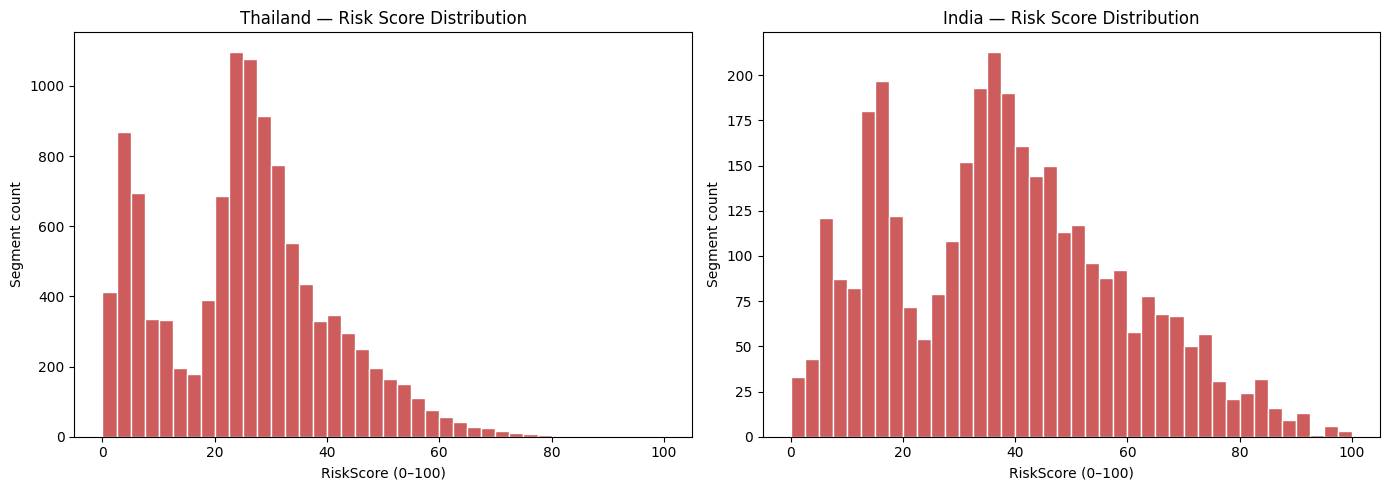

In [8]:
# Score distribution histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, gdf) in zip(axes, [('Thailand', thai_gdf), ('India', india_gdf)]):
    ax.hist(gdf['RiskScore'], bins=40, color='indianred', edgecolor='white')
    ax.set_title(f'{name} \u2014 Risk Score Distribution')
    ax.set_xlabel('RiskScore (0\u2013100)')
    ax.set_ylabel('Segment count')

plt.tight_layout()
plt.show()

## Interactive Maps

In [9]:
tier_colours = {
    'Low':      '#2ecc71',
    'Medium':   '#f39c12',
    'High':     '#e74c3c',
    'Critical': '#8e44ad',
}

legend_html = """
<div style="position:fixed;bottom:40px;left:40px;z-index:1000;
            background:white;padding:15px;border-radius:8px;
            box-shadow:2px 2px 6px rgba(0,0,0,.3);font-family:Arial;">
  <b style="font-size:14px;">Risk Score</b><br><br>
  <span style="color:#8e44ad;">&#9646;</span> Critical (75\u2013100)<br>
  <span style="color:#e74c3c;">&#9646;</span> High (50\u201375)<br>
  <span style="color:#f39c12;">&#9646;</span> Medium (25\u201350)<br>
  <span style="color:#2ecc71;">&#9646;</span> Low (0\u201325)<br>
</div>
"""

def build_map(gdf, road_name_col=None):
    bounds = gdf.total_bounds
    center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]
    m = folium.Map(location=center, zoom_start=6, tiles='CartoDB dark_matter')

    for _, row in gdf.iterrows():
        tier   = str(row['PriorityTier'])
        colour = tier_colours.get(tier, '#888888')
        road   = row[road_name_col] if road_name_col and road_name_col in gdf.columns else 'N/A'

        popup_html = f"""
        <div style="font-family:Arial;width:280px;">
          <h4 style="color:{colour};margin-bottom:8px;">{tier} Priority</h4>
          <table style="width:100%;font-size:12px;">
            <tr><td><b>Road</b></td><td>{road}</td></tr>
            <tr><td><b>Class</b></td><td>{row['RoadClass']} \u2014 {row['LandUse']}</td></tr>
            <tr><td><b>Image Risk (raw)</b></td><td>{round(row['image_risk_score'], 3)}</td></tr>
            <tr><td><b>Risk Score</b></td><td>{round(row['RiskScore'], 1)} / 100</td></tr>
          </table>
        </div>"""

        folium.GeoJson(
            row['geometry'],
            style_function=lambda _f, c=colour: {'color': c, 'weight': 2, 'opacity': 0.8},
            popup=folium.Popup(popup_html, max_width=300)
        ).add_to(m)

    m.get_root().html.add_child(folium.Element(legend_html))
    return m

In [10]:
thai_map = build_map(thai_gdf, road_name_col='english_ro')
thai_map.save('maps/thailand_risk_identification_map.html')

In [11]:
india_map = build_map(india_gdf)
india_map.save('maps/india_risk_identification_map.html')

### Save the scores

In [12]:
# Save as CSV (tabular)
thai_gdf.to_csv('data/thai_risk_score.csv', index=False)
india_gdf.to_csv('data/india_risk_score.csv', index=False)